# Lab 02：知道 score 就能取樣

對應講義：[第 02 課](../lessons/02_math_toolbox.md)

這個實驗**不訓練任何網路**。我們用一個可以精確算出 score 的分布（常態混合），先把三件事看清楚：

1. score 長什麼樣子（一張箭頭地圖）
2. Langevin 動力學只靠 score 就能取樣，而且雜訊項缺一不可
3. 分得很開、權重不同的兩座山，普通 Langevin 抓不對比例；**加多種程度的雜訊**（annealed Langevin）就可以——這就是擴散模型的出發點

CPU 上全部跑完約 1 分鐘。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


## 1. 一個知道答案的分布

8 個小高斯排成一圈。`GaussianMixture` 提供精確的 `log_prob` 與 `score`（講義 §2.2 的公式）。
右圖的箭頭只畫方向（`normalize=True`）：靠近中心的箭頭其實非常長，全部照實畫會把其他箭頭擠到看不見。

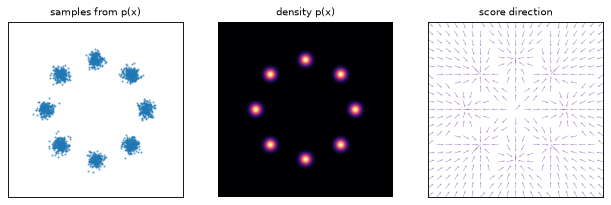

In [2]:
from diffusion_course.data import GaussianMixture
from diffusion_course.viz import new_axes, plot_points, plot_vector_field

LIMIT = 3.5
mixture = GaussianMixture.ring(num_components=8, radius=2.0, std=0.15)

grid_axis = torch.linspace(-LIMIT, LIMIT, 200)
xs, ys = torch.meshgrid(grid_axis, grid_axis, indexing="xy")
grid = torch.stack([xs.flatten(), ys.flatten()], dim=1)
density = mixture.log_prob(grid).exp().reshape(200, 200)

axes = new_axes(3)
plot_points(mixture.sample(2000), axes[0], "samples from p(x)")
axes[1].imshow(density, origin="lower", extent=(-LIMIT, LIMIT, -LIMIT, LIMIT), cmap="magma")
axes[1].set_title("density p(x)", fontsize=9)
axes[1].axis("off")
plot_vector_field(mixture.score, axes[2], title="score direction", normalize=True)
plt.show()

## 2. Langevin 動力學：爬山＋抖動

$$x_{k+1} = x_k + \eta\,\nabla_x \log p(x_k) + \sqrt{2\eta}\,z_k$$

從整個畫面均勀撒下的點出發（這些點大多在「荒野」），只用 score 走 1000 步。

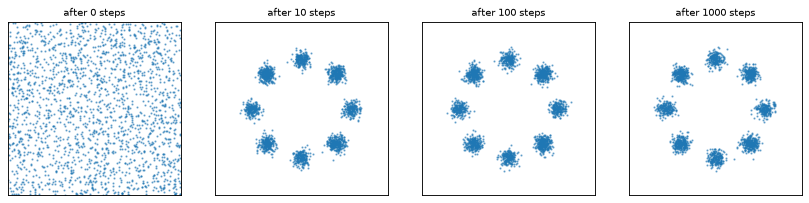

In [3]:
from diffusion_course.score import langevin_dynamics

STEP_SIZE = 0.01
NUM_STEPS = 1000

start = torch.rand(2000, 2) * 2 * LIMIT - LIMIT
_, trajectory = langevin_dynamics(mixture.score, start, STEP_SIZE, NUM_STEPS, save_every=10)

axes = new_axes(4)
for ax, snapshot in zip(axes, [0, 1, 10, 100]):
    plot_points(trajectory[snapshot], ax, f"after {snapshot * 10} steps")
plt.show()

**拿掉雜訊項會怎樣？** 只剩 $x \leftarrow x + \eta\,\nabla \log p$，就是梯度上升：每個點都滑到最近的山頂，分布塌成 8 個點。
用「每個點到最近中心的距離」量化：真實分布的成分標準差是 0.15，二維時平均距離約 $0.15\sqrt{\pi/2} \approx 0.19$。

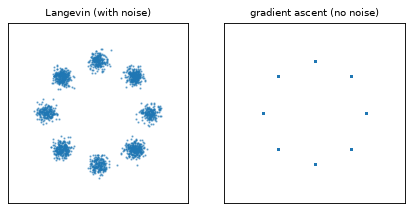

true distribution : 0.188
Langevin          : 0.212
gradient ascent   : 0.000


In [4]:
ascent = start.clone()
for _ in range(NUM_STEPS):
    ascent = ascent + STEP_SIZE * mixture.score(ascent)


def mean_distance_to_nearest_center(points: torch.Tensor) -> float:
    return torch.cdist(points, mixture.means).min(dim=1).values.mean().item()


axes = new_axes(2)
plot_points(trajectory[-1], axes[0], "Langevin (with noise)")
plot_points(ascent, axes[1], "gradient ascent (no noise)")
plt.show()
print(f"true distribution : {mean_distance_to_nearest_center(mixture.sample(20_000)):.3f}")
print(f"Langevin          : {mean_distance_to_nearest_center(trajectory[-1]):.3f}")
print(f"gradient ascent   : {mean_distance_to_nearest_center(ascent):.3f}")

## 3. 步長不是免費的

講義 §2.3 推導過：對標準常態跑 Langevin，步長 $\eta$ 有限時，穩態變異數是 $1/(1-\eta/2)$ 而不是 1。實際量一次：

（第 2 節 Langevin 的平均距離比真實分布大一點，也是這個偏差：每個成分的變異數只有 $0.15^2 = 0.0225$，
步長 0.01 相對於它是 0.44，代入公式變異數放大 $1/(1-0.22) \approx 1.29$ 倍、標準差放大約 1.13 倍，$0.188 \times 1.13 \approx 0.213$。）

In [5]:
print("step   empirical var   theory 1/(1-step/2)")
for step in [0.01, 0.1, 0.5, 1.0]:
    x = torch.zeros(100_000, 1)
    x = langevin_dynamics(lambda v: -v, x, step, num_steps=int(20 / step) + 200)
    print(f"{step:<6} {x.var().item():>13.3f} {1 / (1 - step / 2):>19.3f}")

step   empirical var   theory 1/(1-step/2)


0.01           1.007               1.005


0.1            1.049               1.053
0.5            1.332               1.333


1.0            2.004               2.000


## 4. 失敗案例：兩座不一樣大的山

左邊的山佔 80%，右邊佔 20%，相距 6、各自標準差 0.3。
普通 Langevin 從均勻分布出發：每個點只會滑進「起點所在那一邊」的山，**比例由起點決定，而不是由真正的權重決定**（講義 §2.4 第 3 點）。

In [6]:
two_hills = GaussianMixture(
    means=torch.tensor([[-3.0, 0.0], [3.0, 0.0]]),
    std=0.3,
    weights=torch.tensor([0.8, 0.2]),
)
start = torch.rand(4000, 2) * 10 - 5
plain = langevin_dynamics(two_hills.score, start, step_size=0.01, num_steps=2000)


def left_fraction(points: torch.Tensor) -> float:
    return (points[:, 0] < 0).float().mean().item()


print(f"target left fraction : 0.80")
print(f"plain Langevin       : {left_fraction(plain):.2f}")

target left fraction : 0.80
plain Langevin       : 0.51


**Annealed Langevin**：先在「很模糊」的版本上走，再逐步換成清楚的版本。
給資料加上 $\mathcal{N}(0, \sigma^2 I)$ 的雜訊後，常態混合仍是常態混合，每個成分的標準差變成 $\sqrt{0.3^2 + \sigma^2}$，所以每一層的 score 都能精確算出來。
步長依講義 §2.5 隨 $\sigma^2$ 縮放。

noise levels: [6.0, 3.525, 2.071, 1.216, 0.715, 0.42, 0.247, 0.145, 0.085, 0.05]
annealed Langevin    : 0.79


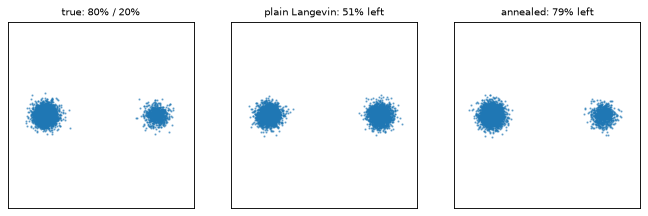

In [7]:
from diffusion_course.score import annealed_langevin_dynamics

SIGMAS = torch.logspace(torch.log10(torch.tensor(6.0)), torch.log10(torch.tensor(0.05)), 10).tolist()
BASE_STEP = 0.1 * SIGMAS[-1] ** 2


def blurred_score(x: torch.Tensor, sigma: float) -> torch.Tensor:
    blurred = GaussianMixture(two_hills.means, (two_hills.std**2 + sigma**2) ** 0.5, two_hills.weights)
    return blurred.score(x)


annealed = annealed_langevin_dynamics(blurred_score, start, SIGMAS, steps_per_level=200, base_step_size=BASE_STEP)
print("noise levels:", [round(s, 3) for s in SIGMAS])
print(f"annealed Langevin    : {left_fraction(annealed):.2f}")

axes = new_axes(3, size=3.4)
plot_points(two_hills.sample(4000), axes[0], "true: 80% / 20%", limit=5)
plot_points(plain, axes[1], f"plain Langevin: {left_fraction(plain):.0%} left", limit=5)
plot_points(annealed, axes[2], f"annealed: {left_fraction(annealed):.0%} left", limit=5)
plt.show()

## 5. 為什麼「模糊化」有用

沿著 $y = 0$ 切一刀，看不同 $\sigma$ 下的密度。$\sigma$ 大時兩座山融成一座、偏向權重大的那邊，score 因此「看得到」權重；
$\sigma$ 小時才分開成兩座。annealed Langevin 就是沿著這一排曲線，從上往下走。

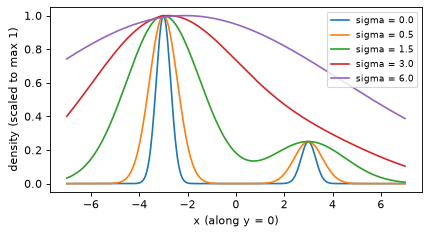

In [8]:
line = torch.stack([torch.linspace(-7, 7, 400), torch.zeros(400)], dim=1)
fig, ax = plt.subplots(figsize=(6, 3))
for sigma in [0.0, 0.5, 1.5, 3.0, 6.0]:
    blurred = GaussianMixture(two_hills.means, (two_hills.std**2 + sigma**2) ** 0.5, two_hills.weights)
    density = blurred.log_prob(line).exp()
    ax.plot(line[:, 0], density / density.max(), label=f"sigma = {sigma}")
ax.set_xlabel("x (along y = 0)")
ax.set_ylabel("density (scaled to max 1)")
ax.legend(fontsize=8)
plt.show()

## 小結

- score 是一張「往高機率處走」的箭頭地圖；它不需要知道正規化常數。
- Langevin 動力學 = 沿 score 爬山 ＋ $\sqrt{2\eta}$ 的抖動，抖動讓樣本按機率比例散開；步長有限會帶來小偏差。
- 模式分得很開時，普通 Langevin 抓不對權重。**先在加了大量雜訊的分布上取樣、再逐步降低雜訊**，就能修正——這正是擴散模型的骨架。

下一步：第 03 課把「一排雜訊等級」變成擴散模型的前向過程。練習題見講義 §5。